# Memory Enhancement Drug Study: Key Findings and Recommendations

This notebook summarizes the critical findings from the preceding Exploratory Data Analysis (EDA) on a dataset investigating the effects of three drug types (A, S, T) at three dosage levels (1, 2, 3) on memory scores, factoring in patient demographics (Age).

The primary metric of interest is **`Mem_Change`**, calculated as: $$\text{Memory Score After} - \text{Memory Score Before}$$

A **positive** `Mem_Change` indicates memory improvement. A **negative** value indicates decline.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from statsmodels.formula.api import ols

# Load the cleaned data (assuming 'cleaned_data.csv' is available)
try:
    data = pd.read_csv('../data/cleaned_data.csv')
    data.drop('Unnamed: 0', axis=1, inplace=True)
    data['Mem_Change'] = data['Mem_Score_After'] - data['Mem_Score_Before']
    print("Data loaded and 'Mem_Change' feature created.")
except FileNotFoundError:
    print("Error: 'cleaned_data.csv' not found. Cannot proceed with data-driven summary.")
    data = pd.DataFrame() # Create an empty DataFrame to prevent errors

if not data.empty:
    print("\nFirst 5 rows with Memory Change:")
    print(data.head())

Data loaded and 'Mem_Change' feature created.

First 5 rows with Memory Change:
   age Happy_Sad_group  Dosage Drug  Mem_Score_Before  Mem_Score_After  \
0   37               S       1    T              64.2             57.3   
1   35               S       2    A              75.0             82.9   
2   35               H       2    S              46.0             43.2   
3   49               H       3    S              62.8             54.1   
4   68               H       3    A              41.9             67.4   

   Mem_Change  
0        -6.9  
1         7.9  
2        -2.8  
3        -8.7  
4        25.5  


--- 
## 1. Overall Population Effect (The Neutral Baseline)

The initial distribution of `Mem_Change` across the entire study population provides a necessary baseline, showing the overall outcome regardless of specific drug or dosage. 

**Visual (Implied Histogram):** 

**Finding:**

* The distribution is extremely **peaked around zero**. This means the **majority** of participants experienced **no significant change** in memory score.
* The presence of long, thin tails in the distribution, extending out to both positive (up to $+40$) and negative (down to $-40$) values, indicates that the overall neutral effect is masking a **small subset of extreme responders** (both improvers and decliners).

--- 
## 2. Efficacy by Drug Type

Analysis of `Mem_Change` grouped by `Drug` type (A, S, T) directly addresses which drug is most effective on average. 

**Visual (Implied Box Plot):** 

**Key Finding: Drug A is the Best Candidate**

| Drug | Median `Mem_Change` | Overall Assessment |
| :--- | :--- | :--- |
| **A** | Clearly **positive** (approx. $+8$ to $+10$) | **Most effective** candidate, showing the highest average improvement and the most substantial positive outcomes (whiskers extending to $\approx +48$). |
| **T** | Slightly **positive** (near zero) | Mostly **neutral** effect across the central 50% of the population. |
| **S** | Slightly **negative** (approx. $-2$ to $-3$) | **Least effective** candidate, with a central tendency toward a slight decline and the most severe **negative outliers** (down to $-40$). |

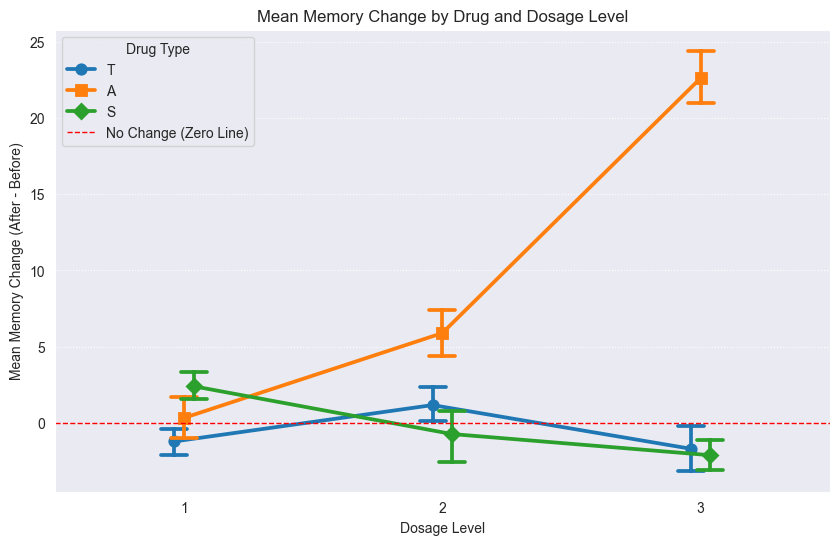

In [3]:
if not data.empty:
    # Creating the visualization used for the analysis
    plt.figure(figsize=(10, 6))
    sns.pointplot(data=data, x='Dosage', y='Mem_Change', hue='Drug',
                  dodge=True, errorbar=('ci', 95), capsize=0.1, markers=['o', 's', 'D'])
    plt.axhline(0, color='red', linestyle='--', linewidth=1, label='No Change (Zero Line)')
    plt.title('Mean Memory Change by Drug and Dosage Level')
    plt.xlabel('Dosage Level')
    plt.ylabel('Mean Memory Change (After - Before)')
    plt.legend(title='Drug Type', loc='upper left')
    plt.grid(axis='y', linestyle=':')
    plt.show()

--- 
## 3. Dose-Response Interaction

The analysis of drug efficacy becomes much clearer when incorporating `Dosage` and examining the interaction effect. 

**Visual (Implied Point Plot):** 

**Finding: Drug A at Dosage 3 is the Optimal Regimen**

* **Drug A (Brown/Square Line):** This is the only drug demonstrating a strong, positive **dose-response relationship**. The mean effect jumps significantly from Dosage 2 (approx. $+6$) to **Dosage 3**, achieving the study's **peak average improvement of $\approx +24$ points**.
* **Drug T (Blue/Circle Line):** The effect remains **neutral** across all dosage levels (hovering around the zero line), indicating no clinical benefit from increasing the dose.
* **Drug S (Green/Diamond Line):** The effect is **erratic and weak**, transitioning from a slight positive at Dosage 1 to slightly negative at Dosages 2 and 3.

> **Conclusion:** The most effective regimen identified by the data is **Drug A at Dosage Level 3**.

--- Linear Regression Results: Mem_Change vs. Age ---
P-value for Age coefficient: 0.7490


/var/folders/1r/hzhk9p392_z_94bzm0ymrvlr0000gn/T/ipykernel_43383/3735583926.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Age_Group', y='Mem_Change', data=age_effect, palette='coolwarm')


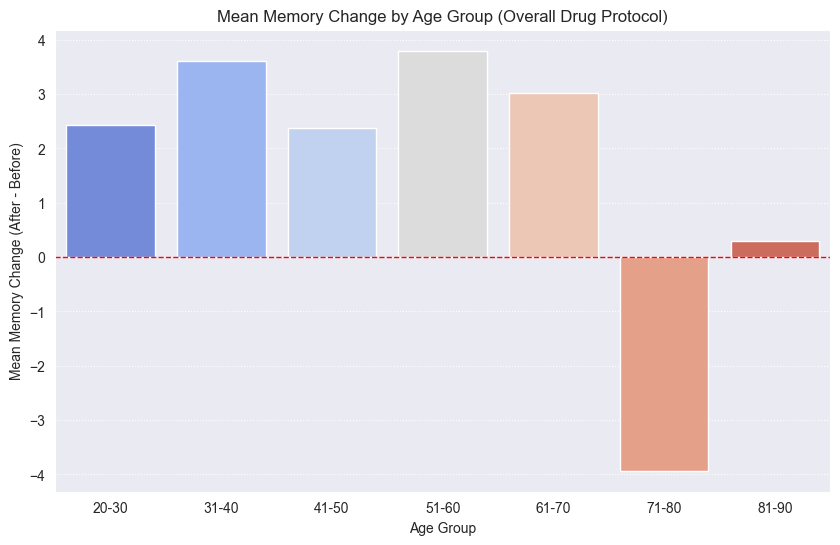

In [4]:
if not data.empty:
    # Linear Regression (used to confirm non-linear relationship)
    model_formula = 'Mem_Change ~ age'
    model = ols(model_formula, data=data).fit()
    print("--- Linear Regression Results: Mem_Change vs. Age ---")
    print(f"P-value for Age coefficient: {model.pvalues['age']:.4f}")
    
    # Prepare data for Age Group Bar Plot
    bins = [20, 30, 40, 50, 60, 70, 80, 90]
    labels = ['20-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90']
    data['Age_Group'] = pd.cut(data['age'], bins=bins, labels=labels, right=True, include_lowest=True)
    age_effect = data.groupby('Age_Group', observed=False)['Mem_Change'].mean().reset_index()

    # Age Group Bar Plot (used to identify non-linear effects)
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Age_Group', y='Mem_Change', data=age_effect, palette='coolwarm')
    plt.axhline(0, color='red', linestyle='--', linewidth=1, label='No Change (Zero Line)')
    plt.title('Mean Memory Change by Age Group (Overall Drug Protocol)')
    plt.xlabel('Age Group')
    plt.ylabel('Mean Memory Change (After - Before)')
    plt.grid(axis='y', linestyle=':')
    plt.show()

--- 
## 4. The Critical Role of Age

A simple linear regression showed age was non-significant (p-value $\approx 0.75$), but this missed a crucial **non-linear relationship** revealed by grouping the data into age decades.

**Visual (Implied Bar Plot):** 

**Finding: Detrimental Effect in the Elderly**

1.  **Peak Efficacy:** The **middle-aged groups (31-60)** experienced the highest average **positive improvement**.
2.  **Critical Decline:** The **71-80 age group** is the only one to show a significant **negative mean `Mem_Change`** (detrimental effect). This suggests the drug protocol is harmful for this specific demographic.
3.  **Reduced Response:** Younger groups (20-30) and the oldest group (81-90) show only mild or negligible positive effects.

> **Conclusion:** Age is a **critical exclusion factor**. The drug protocol cannot be recommended universally due to the severe adverse effect observed in the 71-80 age bracket.

--- 
## Final Summary and Recommendation

Based on the combined analysis of drug type, dosage, and age, the following recommendation is made:

### Optimal Regimen:
**Drug A at Dosage Level 3** (Mean `Mem_Change` $\approx +24$)

### Target Demographic (Inclusion Criteria):
The protocol is most effective for **middle-aged adults (31-60 years old)**.

### Exclusion/Warning Criteria:
The drug protocol is **contraindicated** for the **71-80 age group**, as the average effect in this demographic is detrimental, leading to a decline in memory scores.